<a href="https://colab.research.google.com/github/Pedroct06/Curso-LLM-From-Scratch/blob/main/Aula07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import json
import os
import requests


def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        text_data = response.text
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data

file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


In [2]:
print("Example entry:\n", data[50])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


In [3]:
print("Another exampled entry:\n", data[999])

Another exampled entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


Formatando o estilo de resposta

In [4]:
def format_input(entry):
  instruction_text = (
      f"Below is an instruction that describes a task. "
      f"Write a response that appropriately completes the request."
      f"\n\n### Instruction:\n{entry['instruction']}"
  )

  input_text = f"\n\n### Input:\n{entry['input']}" if entry['input'] else ""
  return instruction_text + input_text

Resposta formatada com o input aparecendo

In [5]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


Resposta formatada sem o input

In [6]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


Dividindo o dataset em treino, teste e validação

In [7]:
train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion

train_data = data[:train_portion]
test_data = data[train_portion : train_portion + test_portion]
val_data = data[train_portion + test_portion:]

In [8]:
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


Pré-tokenizando o dataset

In [9]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
  def __init__(self, data, tokenizer):
    self.data = data

    self.encoded_text = []
    for entry in data:
      instruction_plus_input = format_input(entry)
      response_text = f"\n\n###Response:\n{entry['output']}"
      full_text = instruction_plus_input + response_text
      self.encoded_text.append(
          tokenizer.encode(full_text)
      )

  def __getitem__(self, index):
    return self.encoded_text[index]

  def __len__(self):
    return len(self.data)

In [10]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [11]:
def custom_collate_draft_1(batch, pad_token_id = 50256, device = "cpu"):
  #Acha a maior sequencia no batch e aumenta o tamanho maximo em 1, o que adiciona um token de padding extra
  batch_max_length = max(len(item)+1 for item in batch)

  inputs_lst = []
  for item in batch:
    new_item = item.copy()
    new_item += [pad_token_id]
    padded = (new_item + [pad_token_id] * (batch_max_length - len(new_item)))

    inputs = torch.tensor(padded[:-1])
    inputs_lst.append(inputs)

  inputs_tensor = torch.stack(inputs_lst).to(device)
  return inputs_tensor

In [12]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


In [13]:
def custom_collate_draft_2(batch, pad_token_id = 50256, device = "cpu"):
  batch_max_length = max(len(item)+1 for item in batch)
  inputs_lst, targets_lst = [], []
  for item in batch:
    new_item = item.copy()
    new_item += [pad_token_id]
    padded = (new_item + [pad_token_id] * (batch_max_length - len(new_item)))
    inputs = torch.tensor(padded[:-1])
    targets = torch.tensor(padded[:-1])
    inputs_lst.append(inputs)
    targets_lst.append(targets)

  inputs_tensor = torch.stack(inputs_lst).to(device)
  targets_tensor = torch.stack(targets_lst).to(device)
  return inputs_tensor, targets_tensor

In [14]:
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


In [15]:
def custom_collate_fn(batch, pad_token_id = 50256, ignore_index = -100,
                      allowed_max_length = None, device="cpu"):
  batch_max_length = max(len(item)+1 for item in batch)
  inputs_lst, targets_lst = [], []

  for item in batch:
    new_item = item.copy()
    new_item += [pad_token_id]
    padded = (new_item + [pad_token_id] * (batch_max_length - len(new_item)))

    inputs = torch.tensor(padded[:-1])
    targets = torch.tensor(padded[1:])

    mask = targets == pad_token_id
    indices = torch.nonzero(mask).squeeze()
    if indices.numel() > 1:
      targets[indices[1:]] = ignore_index


    if allowed_max_length is not None:
      inputs = inputs[:allowed_max_length]
      targets = targets[:allowed_max_length]

    inputs_lst.append(inputs)
    targets_lst.append(targets)

  inputs_tensor = torch.stack(inputs_lst).to(device)
  targets_tensor = torch.stack(targets_lst).to(device)
  return inputs_tensor, targets_tensor

In [16]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


In [17]:
logits_1 = torch.tensor([[-1.0, 1.0],
                         [-0.5, 1.5]])
targets_1 = torch.tensor([0,1])

loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


In [18]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]
)
targets_2 = torch.tensor([0, 1, 1])

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


In [19]:
targets_3 = torch.tensor([0,1,-100])

loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


Criando o data loader

In [20]:
if torch.cuda.is_available():
  device = torch.device("cuda")
elif torch.backends.mps.is_available():
  major, minor = map(int, torch.__version__.split(".")[:2])
  if (major, minor) >= (2, 9):
    device = torch.device("mps")
  else:
    device = torch.device("cpu")
else:
  device = torch.device("cpu")

print("Device", device)

Device cuda


In [21]:
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,
    device = device,
    allowed_max_length = 1024
)

In [22]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size = batch_size,
    collate_fn= customized_collate_fn,
    shuffle = True,
    drop_last = True,
    num_workers= num_workers
)

In [23]:
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size= batch_size,
    collate_fn = customized_collate_fn,
    shuffle = False,
    drop_last = False,
    num_workers= num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size = batch_size,
    collate_fn = customized_collate_fn,
    shuffle = False,
    drop_last = False,
    num_workers= num_workers
)

Verificando as dimensões dos inputs e dos targets

In [24]:
print("Train Loader:")
for inputs, targets in train_loader:
  print(inputs.shape, targets.shape)

Train Loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.

In [25]:
print(inputs[0])

tensor([21106,   318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,
          257,  2882,   326, 20431, 32543,   262,  2581,    13,   198,   198,
        21017, 46486,    25,   198, 30003,  6525,   262,  6827,  1262,   257,
          985,   576,    13,   198,   198, 21017, 23412,    25,   198,   464,
         5156,   318,   845, 13779,    13,   198,   198, 21017, 31077,    25,
          198,   464,  5156,   318,   355, 13779,   355,   257,  4936,    13,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256],
       device='cuda:0')


In [26]:
print(targets[0])

tensor([  318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,   257,
         2882,   326, 20431, 32543,   262,  2581,    13,   198,   198, 21017,
        46486,    25,   198, 30003,  6525,   262,  6827,  1262,   257,   985,
          576,    13,   198,   198, 21017, 23412,    25,   198,   464,  5156,
          318,   845, 13779,    13,   198,   198, 21017, 31077,    25,   198,
          464,  5156,   318,   355, 13779,   355,   257,  4936,    13, 50256,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100],
       device='cuda:0')


In [27]:
import os
import requests

if True:
    url = (
        "https://raw.githubusercontent.com/Pedroct06/Curso-LLM-From-Scratch/refs/heads/main/Aulas_anteriores.py"
    )
    file_path = "Aulas_anteriores.py"

    response = requests.get(url, timeout=30)
    response.raise_for_status()
    with open(file_path, "wb") as f:
        f.write(response.content)


In [28]:
if True:
    url = (
        "https://raw.githubusercontent.com/Pedroct06/Curso-LLM-From-Scratch/refs/heads/main/loadgpt.py"
    )
    file_path = "loadgpt.py"

    response = requests.get(url, timeout=30)
    response.raise_for_status()
    with open(file_path, "wb") as f:
        f.write(response.content)


Carregando a LLM pre-treinada

In [29]:
import sys

from Aulas_anteriores import GPTModel, load_weights_into_gpt
from loadgpt import download_and_load_gpt2

BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2( model_size = model_size, models_dir = "gpt2")
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();


checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 138kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:01<00:00, 732kiB/s]
hparams.json: 100%|██████████| 91.0/91.0 [00:00<00:00, 183kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 1.42G/1.42G [09:00<00:00, 2.63MiB/s]
model.ckpt.index: 100%|██████████| 10.4k/10.4k [00:00<00:00, 13.4MiB/s]
model.ckpt.meta: 100%|██████████| 927k/927k [00:01<00:00, 639kiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 459kiB/s]


In [30]:
torch.manual_seed(123)
input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [31]:
from Aulas_anteriores import(
    generate,
    text_to_token_ids,
    token_ids_to_text
)

token_ids = generate(
    model = model,
    idx = text_to_token_ids(input_text, tokenizer),
    max_new_tokens = 35,
    context_size = BASE_CONFIG["context_length"],
    eos_id = 50256
)

generated_text = token_ids_to_text(token_ids, tokenizer)

In [32]:
response_text = (generated_text[len(input_text):].replace("###Response:", "").strip())
print(response_text)

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


In [33]:
from Aulas_anteriores import(
    calc_loss_loader,
    train_model_simple
)

In [34]:
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
  train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
  val_loss = calc_loss_loader(val_loader, model, device, num_batches =5)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.9301892280578614
Validation loss: 3.862861442565918


In [35]:
import time
start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr = 0.00005, weight_decay=0.1)

num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs = num_epochs, eval_freq = 5, eval_iter = 5,
    start_context = format_input(val_data[0]), tokenizer = tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.716, Val loss 2.702
Ep 1 (Step 000005): Train loss 1.198, Val loss 1.124
Ep 1 (Step 000010): Train loss 0.869, Val loss 0.957
Ep 1 (Step 000015): Train loss 0.863, Val loss 0.916
Ep 1 (Step 000020): Train loss 0.785, Val loss 0.889
Ep 1 (Step 000025): Train loss 0.766, Val loss 0.860
Ep 1 (Step 000030): Train loss 0.801, Val loss 0.839
Ep 1 (Step 000035): Train loss 0.715, Val loss 0.807
Ep 1 (Step 000040): Train loss 0.665, Val loss 0.800
Ep 1 (Step 000045): Train loss 0.631, Val loss 0.790
Ep 1 (Step 000050): Train loss 0.665, Val loss 0.779
Ep 1 (Step 000055): Train loss 0.760, Val loss 0.763
Ep 1 (Step 000060): Train loss 0.718, Val loss 0.744
Ep 1 (Step 000065): Train loss 0.652, Val loss 0.736
Ep 1 (Step 000070): Train loss 0.535, Val loss 0.729
Ep 1 (Step 000075): Train loss 0.573, Val loss 0.728
Ep 1 (Step 000080): Train loss 0.607, Val loss 0.722
Ep 1 (Step 000085): Train loss 0.512, Val loss 0.709
Ep 1 (Step 000090): Train loss 0.569, Val loss

Extraindo e salvando as responses

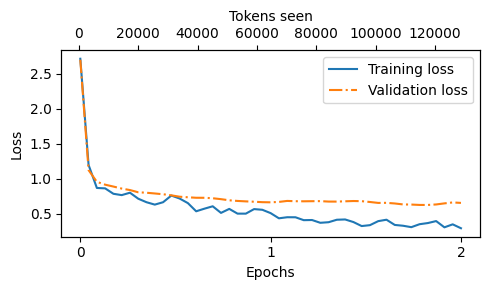

In [36]:
from Aulas_anteriores import plot_losses

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [37]:
torch.manual_seed(123)

for entry in test_data[:3]:
  input_text = format_input(entry)
  token_ids = generate(model = model,
                       idx = text_to_token_ids(input_text, tokenizer).to(device),
                       max_new_tokens = 256,
                       context_size = BASE_CONFIG["context_length"],
                       eos_id = 50256)

  generated_text = token_ids_to_text(token_ids, tokenizer)
  response_text = (
      generated_text[len(input_text):].replace("### Response:", "").strip()

  )
  print(input_text)
  print(f"\nCorrect response:\n>> {entry['output']}")
  print(f"\nModel response:\n>> {response_text.strip()}")
  print("------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response


In [39]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total= len(test_data)):
  input_text = format_input(entry)
  token_ids = generate(
      model = model,
      idx = text_to_token_ids(input_text, tokenizer).to(device),
      max_new_tokens = 256,
      context_size = BASE_CONFIG["context_length"],
      eos_id = 50256
  )

  generated_text = token_ids_to_text(token_ids, tokenizer)
  response_text = generated_text[len(input_text):].replace("### Response:", "").strip()

  test_data[i]["model_response"] = response_text

with open("instruction-data-with-response.json", "w") as file:
  json.dump(test_data, file, indent = 4)

100%|██████████| 110/110 [01:33<00:00,  1.18it/s]


In [40]:
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': '###Response:\nThe car is as fast as a cheetah.'}


In [41]:
import re

file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL)}-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

Model saved as gpt2-medium355M-sft.pth


Fazendo a validação

Instalando o ollama

In [47]:
!apt-get update -qq
!apt-get install -y zstd

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 69 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 2s (330 kB/s)
Selecting previously unselected package zstd.
(Reading database ... 122579 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...


In [48]:
!curl -fsSL https://ollama.com/install.sh | sh

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [49]:
!ollama --version

In [50]:
!ollama serve > /tmp/ollama.log 2>&1 &

In [51]:
!ollama list

NAME    ID    SIZE    MODIFIED 


In [54]:
!ollama pull llama3

In [56]:
!ollama run llama3 "Say hello"

Hello! It's nice to meet you. Is there something I can help you with or wou
would you like to chat?



In [52]:
import psutil

def check_if_running(process_name):
  running = False
  for proc in psutil.process_iter(["name"]):
    if process_name in proc.info["name"]:
      running = True
      break
  return running

ollama_running = check_if_running("ollama")

if not ollama_running:
  raise RuntimeError("Ollama not running. Launch ollama before proceeding.")
print("Ollama running:", check_if_running("ollama"))

Ollama running: True


In [57]:
import requests

def query_model(
    prompt,
    model = "llama3",
    url = "http://localhost:11434/api/chat"
):
  data = {
      "model": model,
      "messages": [{"role": "user", "content": prompt}],
      "options": {
          "seed":123,
          "temperature":0,
          "num_ctx": 2048
      }
  }
  with requests.post(url, json=data, stream=True, timeout=300) as r:
      r.raise_for_status()
      response_data = ""
      for line in r.iter_lines(decode_unicode=True):
          if not line:
              continue
          response_json = json.loads(line)
          if "message" in response_json:
              response_data += response_json["message"]["content"]

  return response_data


model = "llama3"
result = query_model("What do Llamas eat?", model)
print(result)

Llamas are herbivores, which means they primarily eat plants and plant-based foods. Their diet typically consists of:

1. Grasses: Llamas love to graze on various types of grasses, including tall grasses, short grasses, and even weeds.
2. Hay: Hay, such as alfalfa or timothy hay, is a staple in a llama's diet. It provides essential fiber and nutrients.
3. Grains: Llamas may also eat grains like oats, barley, or corn, although these should be given in moderation due to their high calorie content.
4. Fruits and vegetables: Llamas enjoy fruits and vegetables like apples, carrots, and sweet potatoes. These can be given as treats or added to their regular diet.
5. Leaves and shrubs: In the wild, llamas may eat leaves, shrubs, and other vegetation.
6. Minerals: Llamas need access to minerals like calcium, phosphorus, and salt to maintain strong bones and overall health.

A typical llama's diet might include:

* 70-80% grasses and hay
* 10-20% grains and fruits
* 5-10% minerals and supplement

In [60]:
import subprocess
import time
import requests

# Inicia o servidor Ollama
ollama_process = subprocess.Popen(
    ["ollama", "serve"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

# Espera o servidor iniciar
for _ in range(20):
    try:
        requests.get("http://localhost:11434/api/tags", timeout=2)
        print("Ollama está rodando!")
        break
    except:
        time.sleep(1)
else:
    print("Ollama não iniciou.")

Ollama está rodando!


In [61]:
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
    )
    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore:")
    print(">>", query_model(prompt))
    print("\n-------------------------")


Dataset response:
>> The car is as fast as lightning.

Model response:
>> ###Response:
The car is as fast as a cheetah.

Score:
>> To score the model response, I'll compare it to the correct output. Here's the evaluation:

* The model response uses a simile, which is the correct format for rewriting the sentence.
* The comparison used in the model response ("as fast as a cheetah") is a good one, as cheetahs are known for their speed.
* However, the model response doesn't quite match the original sentence's level of extremity. The input sentence says the car is "very fast", implying an exceptional level of speed. The model response's comparison to a cheetah, while fast, might not convey the same level of exceptional speed.

Based on this evaluation, I'd score the model response a 70 out of 100. The model response is close to the correct output, but could be improved by using an even more extreme comparison to convey the same level of exceptional speed as the original sentence.

-------

In [62]:
def generate_model_scores(json_data, json_key, model="llama3"):
  scores = []
  for entry in tqdm(json_data, desc = "Scoring entries"):
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and corret output `{entry['output']}`, "
        f"score the model response `{entry[json_key]}` "
        f" on a scale from 0 to 100, where 100 is the best score. "
        f"Respond with the integer number only."
    )
    score = query_model(prompt, model)
    try:
      scores.append(int(score))
    except ValueError:
      print(f"Could not convert score: {score}")
      continue

  return scores

scores = generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score: {sum(scores)/ len(scores):.2f}\n")

Scoring entries: 100%|██████████| 110/110 [00:15<00:00,  7.23it/s]

Number of scores: 110 of 110
Average score: 40.40

